In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    'Client_Type': np.random.choice(['Startup', 'SME', 'Enterprise'], 100),
    'Project_Duration': np.random.randint(1, 24, 100),
    'Team_Size': np.random.randint(2, 20, 100),
    'Complexity_Level': np.random.choice(['Low', 'Medium', 'High'], 100),
    'Project_Budget': np.random.randint(5000, 100000, 100)
}

df = pd.DataFrame(data)

df.to_csv('coretech_clients.csv', index=False)

print(df.head())

  Client_Type  Project_Duration  Team_Size Complexity_Level  Project_Budget
0  Enterprise                12         18           Medium           91672
1     Startup                 8         18              Low           78847
2  Enterprise                11          3           Medium           87750
3  Enterprise                19          3              Low           84634
4     Startup                17          6           Medium           33251


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("coretech_clients.csv")

print(df.head())
print(df.info())

  Client_Type  Project_Duration  Team_Size Complexity_Level  Project_Budget
0  Enterprise                12         18           Medium           91672
1     Startup                 8         18              Low           78847
2  Enterprise                11          3           Medium           87750
3  Enterprise                19          3              Low           84634
4     Startup                17          6           Medium           33251
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Client_Type       100 non-null    object
 1   Project_Duration  100 non-null    int64 
 2   Team_Size         100 non-null    int64 
 3   Complexity_Level  100 non-null    object
 4   Project_Budget    100 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 4.0+ KB
None


In [5]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

# Encode categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Client_Type  Project_Duration  Team_Size  Complexity_Level  Project_Budget
0            0                12         18                 2           91672
1            2                 8         18                 1           78847
2            0                11          3                 2           87750
3            0                19          3                 1           84634
4            2                17          6                 2           33251


/tmp/ipykernel_21387/2903099726.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_21387/2903099726.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [7]:
X = df.drop("Project_Budget", axis=1)
y = df["Project_Budget"]

In [8]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (80, 4)
Testing Data: (20, 4)


In [10]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [11]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE : 27108.12471926909
MSE : 919746889.560756
RMSE: 30327.32908715761
R2 Score: -0.035048360311751514


In [12]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

In [13]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2 Score:", r2_ridge)

Ridge Regression Results
MAE : 27012.001204957465
MSE : 915110626.4696728
RMSE: 30250.79546837856
R2 Score: -0.0298308851945579


In [14]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MAE": [mae_lr, mae_ridge],
    "MSE": [mse_lr, mse_ridge],
    "RMSE": [rmse_lr, rmse_ridge],
    "R2 Score": [r2_lr, r2_ridge]
})

print(comparison)

               Model           MAE           MSE          RMSE  R2 Score
0  Linear Regression  27108.124719  9.197469e+08  30327.329087 -0.035048
1   Ridge Regression  27012.001205  9.151106e+08  30250.795468 -0.029831


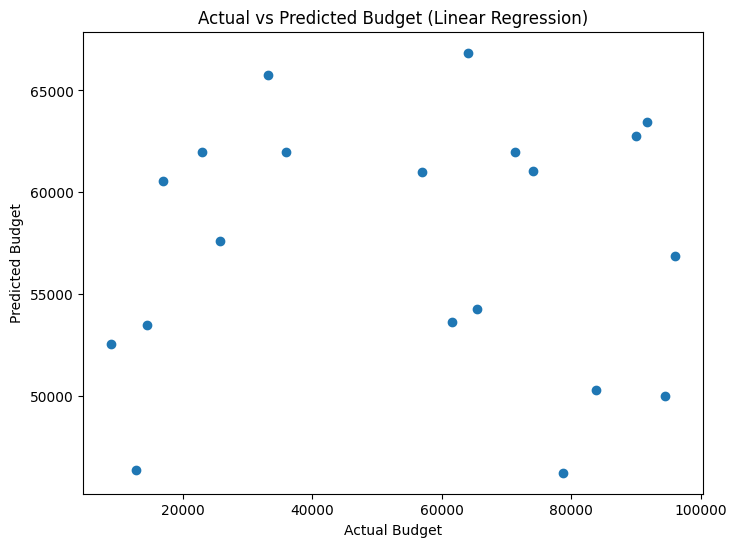

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Budget")
plt.ylabel("Predicted Budget")
plt.title("Actual vs Predicted Budget (Linear Regression)")

plt.show()